## Assignment 01: Intensity Transformations and Neighborhood Filtering

**Index No:** 230186E  
**Name:** Fernando W. H. D.  
**GitHub:** https://github.com/himashafdo/EN3160-A01-Intensity-Transformations-and-Neighborhood-Filtering.git

### Because of the 20-page restriction I have not included the full code in these cells(eg. plotting code but the plots are added), and included full implemented code for each part in each question in [Individual code scripts](Individual%20code%20scripts/)

In [3]:
# libraries I used
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 

## Question 01 ##

### (a) ###

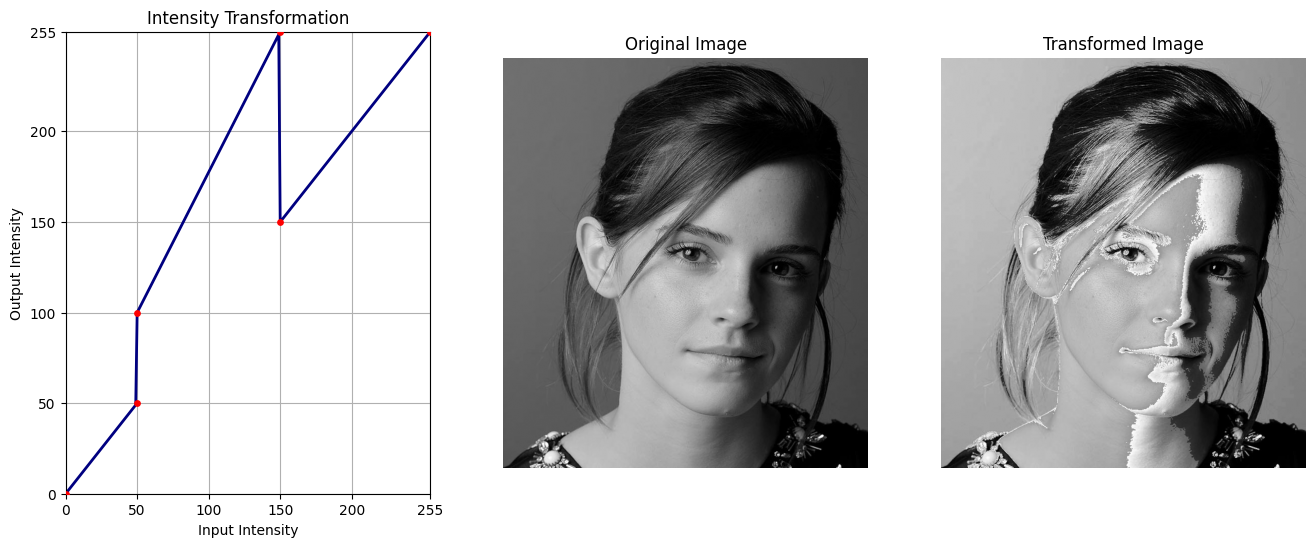

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 

def intensity_transform(im, breakpoints):
    """
        Here I defined the intensity transformation function to precompute values for each pixel value in the range [0, 255] 
        and store them in a lookup table, since it is much faster than computing value for the pixel value each time.    
    """
    out = im.copy().astype(float)

    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x2 == x1:
            continue # skips vertical lines as no need of computing slope there.
        else:
            slope = (y2 - y1) / (x2 - x1)
            mask = (im >= x1) & (im <= x2)
            out[mask] = y1 + slope * (im[mask] - x1)

    return out

path = "images/emma_gray.jpg"
im = np.array(Image.open(path).convert('L'))

breakpoints = [[0, 0],[50, 50],[50, 100],[150, 255],[150, 150],[255, 255]]

out = intensity_transform(im, breakpoints)

xs = np.arange(0, 256)
lut = intensity_transform(xs, breakpoints)

bp = np.array(breakpoints)

In [8]:
def plot_transform(im, breakpoints, index=1):
    """This was created to simplify the plottings in experiments"""
    out = intensity_transform(im, breakpoints) # previously defined intensity transformation function applied here
    xs = np.arange(0, 256)
    lut = intensity_transform(xs, breakpoints)

    bp = np.array(breakpoints)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))

    ax[0].plot(xs, lut, color='navy', linewidth=2)
    ax[0].scatter(bp[:, 0], bp[:, 1], color='red', s=15, zorder=5)
    ax[0].set_xlabel('Input Intensity'); ax[0].set_ylabel('Output Intensity'); ax[0].set_title('Intensity Transformation')
    ax[0].set_xlim(0, 255); ax[0].set_ylim(0, 255)
    ax[0].set_xticks([0, 50, 100, 150, 200, 255]); ax[0].set_yticks([0, 50, 100, 150, 200, 255]); ax[0].grid()

    ax[1].imshow(im, cmap='gray'); ax[1].set_title('Original Image'); ax[1].axis('off')

    ax[2].imshow(out.astype(np.uint8), cmap='gray'); ax[2].set_title(f'Transformed Image {index}'); ax[2].axis('off')
    plt.show()

    return out

### (b) ###

I have done multiple experiments with different breakpoints and some with guessing and with analysing the histogram of the original image. There I found that the the Transformed image 3 have the most visually pleasing image output which was found by using the S-curve technique where I fletten out the too dark and too bright features to get more range to important details. Shortlisted bp-arrays and respective outputs (including the best one) are listed bellow.

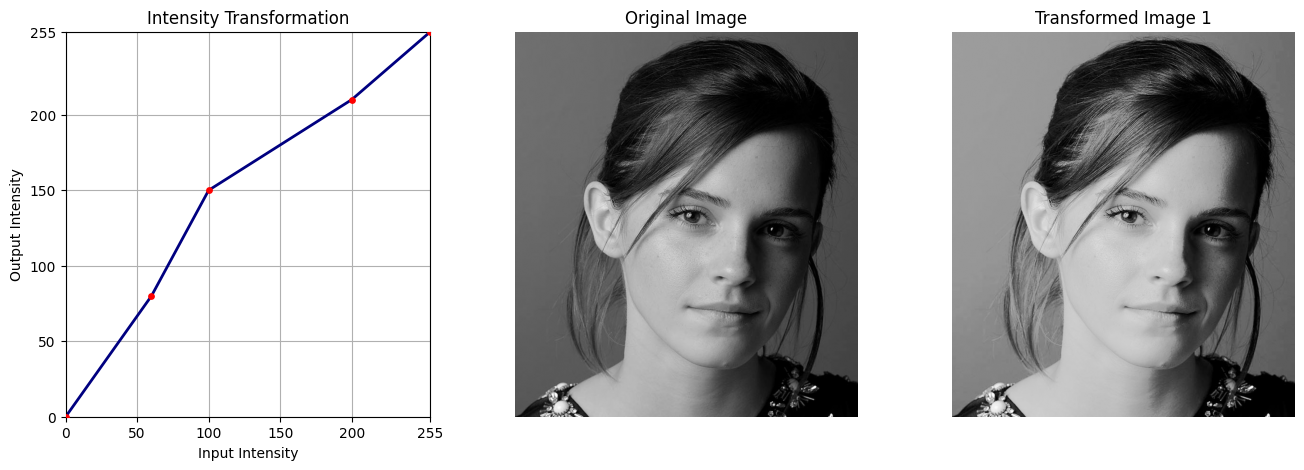

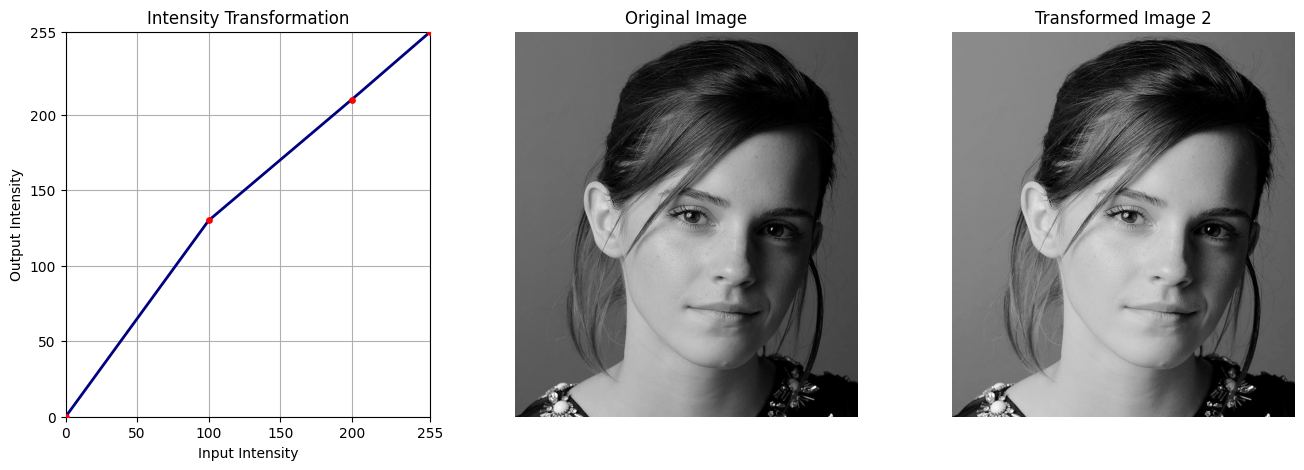

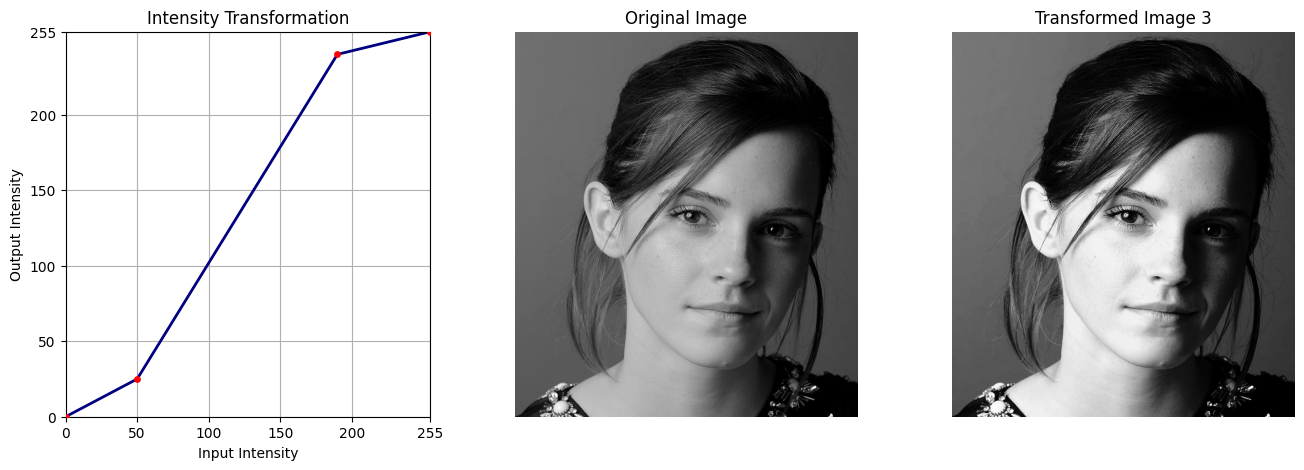

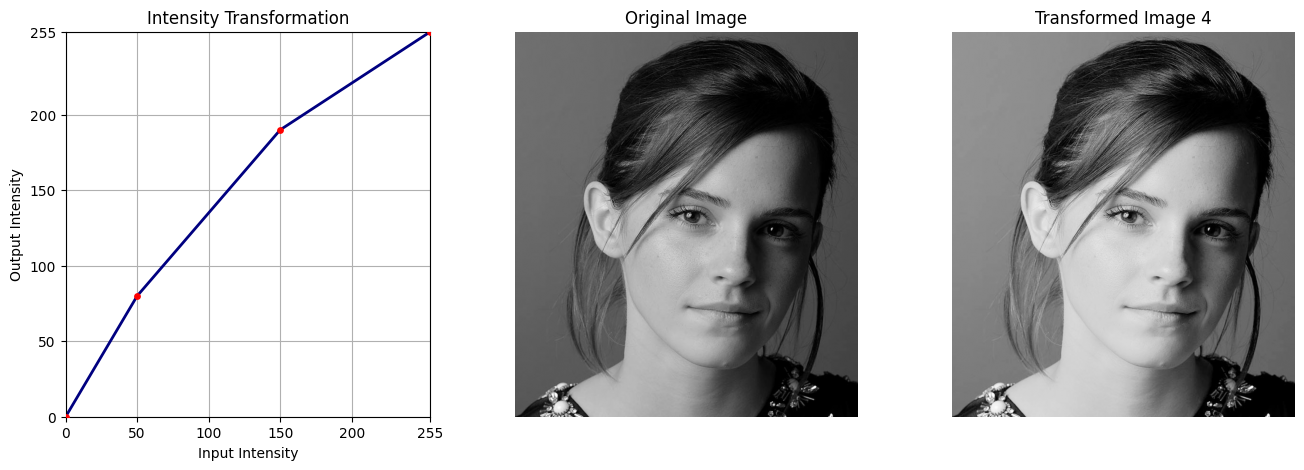

In [61]:
#plt.hist(im.ravel(), bins=256, range=(0,255))
#plt.show() #histogram of the original image

breakpoints_1= [[0, 0], [60, 80], [100, 150], [200, 210], [255, 255]]
out1 = plot_transform(im, breakpoints_1,1)

breakpoints_2= [[0, 0], [100, 130], [200, 210], [255, 255]]
out2 = plot_transform(im, breakpoints_2,2)

breakpoints_3= [[0, 0], [50, 25], [190, 240], [255, 255]]
out3 = plot_transform(im, breakpoints_3,3)

breakpoints_4= [[0, 0], [50, 80], [150, 190], [255, 255]]
out4 = plot_transform(im, breakpoints_4,4)


### Comparisson, Intepretation and Disscussion ###

The given breakpoints in the original transformation, introduce a discontinuity at intensity 150, causing pixels just below and just above this threshold to be mapped to very different output values. This is what produces that  false edge in part (a).

With respect to other experimented outputs (which avoided discontinuities), Transformation 3 is more visually pleasing. This is because in there the features that needs to be highlighted are highlighted and given a brader range to display fine textures(skin texture, hair strands, etc.) more acurately while smoothely flattening out the brightest and darkest pixels.

This confirms that breakpoint placement should be guided by where detail is concentrated in the image's intensity distribution, rather than applied uniformly. Steepening the curve over the dominant intensity range increases local contrast and perceptual sharpness, while flattening it at the extremes avoids introducing noise or losing information in already low-detail regions.

## Question 02 ##

Here I used the previously defined intensity_tranform and plot_transform functions as mentioned and after analysing the hisogram for the image I idnetified the White Matter and Gray Matter regions are roughly [135, 160]and [180, 240] respectively.

### (a) white matter

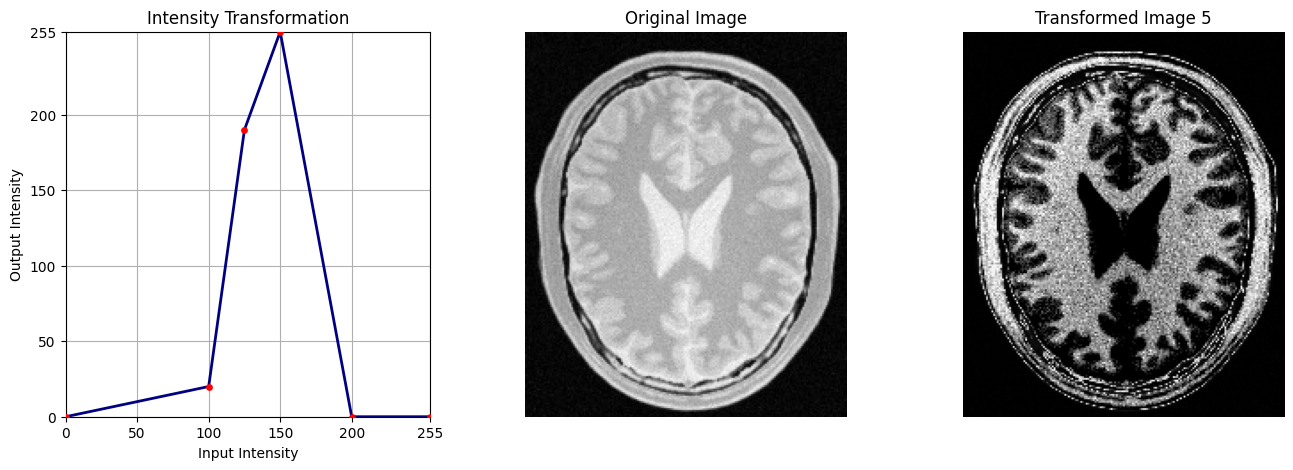

In [26]:
im2 = np.array(Image.open("images/q2.jpeg").convert('L'))


breakpoints_5= [[0, 0], [100, 20], [125,190], [150,255],[200, 0], [255,0]]
out5 = plot_transform(im2, breakpoints_5,5)

### (b) gray matter


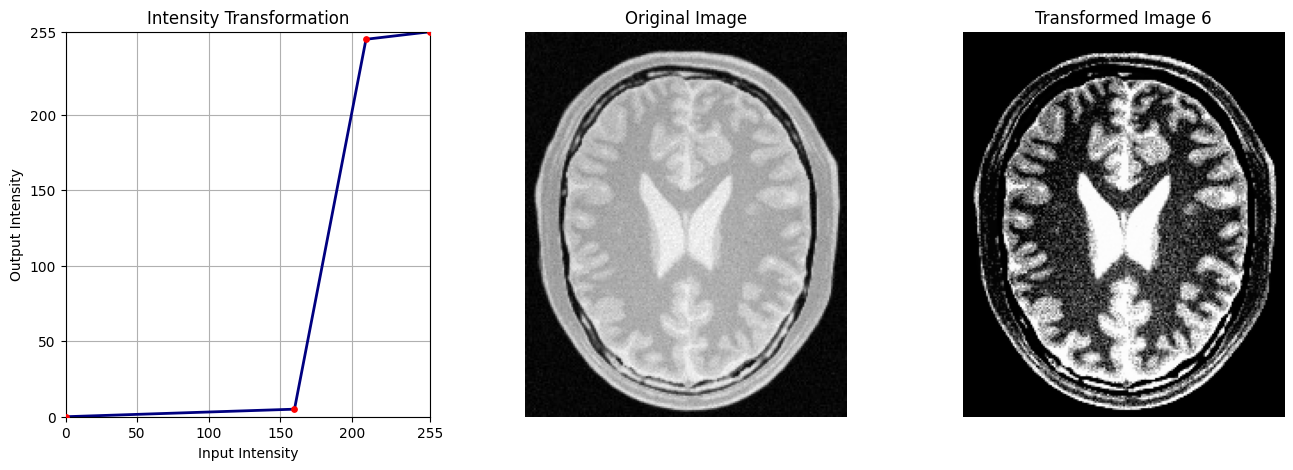

In [30]:
breakpoints_6= [[0, 0], [160, 5],[210, 250], [255, 255]]
out6 = plot_transform(im2, breakpoints_6,6)

## Question 03 

### (a)

After converting BGR of cv2 read image to LAB I normalized the l channel and applied gamma correction to that channel. Here after adjusting for gamma values I settled with gamma = 0.65 for the best possible result. 

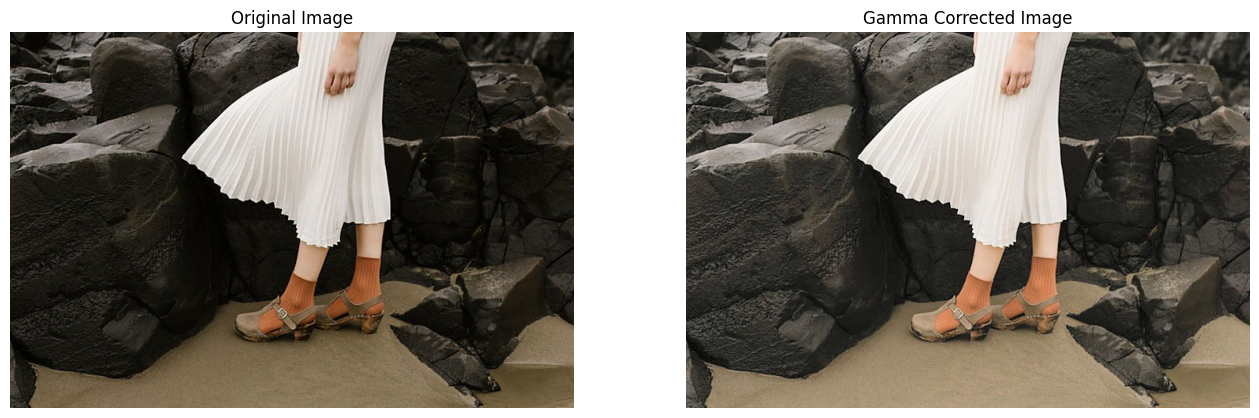

In [ ]:
im3 = cv2.imread("images/q3.jpeg")
lab_im = cv2.cvtColor(im3, cv2.COLOR_BGR2LAB)

l_channel, a_channel, b_channel = cv2.split(lab_im)

gamma = 0.65

normalized_l = l_channel / 255.0
corrected_l = np.power(normalized_l, gamma) * 255.0
corrected_l = np.uint8(np.clip(corrected_l, 0, 255))

corrected_lab = cv2.merge((corrected_l, a_channel, b_channel))
corrected_im = cv2.cvtColor(corrected_lab, cv2.COLOR_LAB2BGR)


### (b) 

The histograms differ notably in couple of ways.First in the gamma-corrected histogram, the overall distribution shifts noticeably toward the brighter region of the scale. Specifically, the primary low-intensity peak around value ~20 in the original image is stretched and shifted rightward to approximately ~(40-50), effectively expanding the dynamic range of darker tissue details and background tones. Secondly, the corrected histogram displays characteristic comb-like spikes and gaps this is because applying a continuous non-linear function to 8-bit integer pixel values causes certain output levels to be skipped while others accumulate multiple mapped values.

Text(0.5, 1.0, 'Histogram of Gamma Corrected Image')

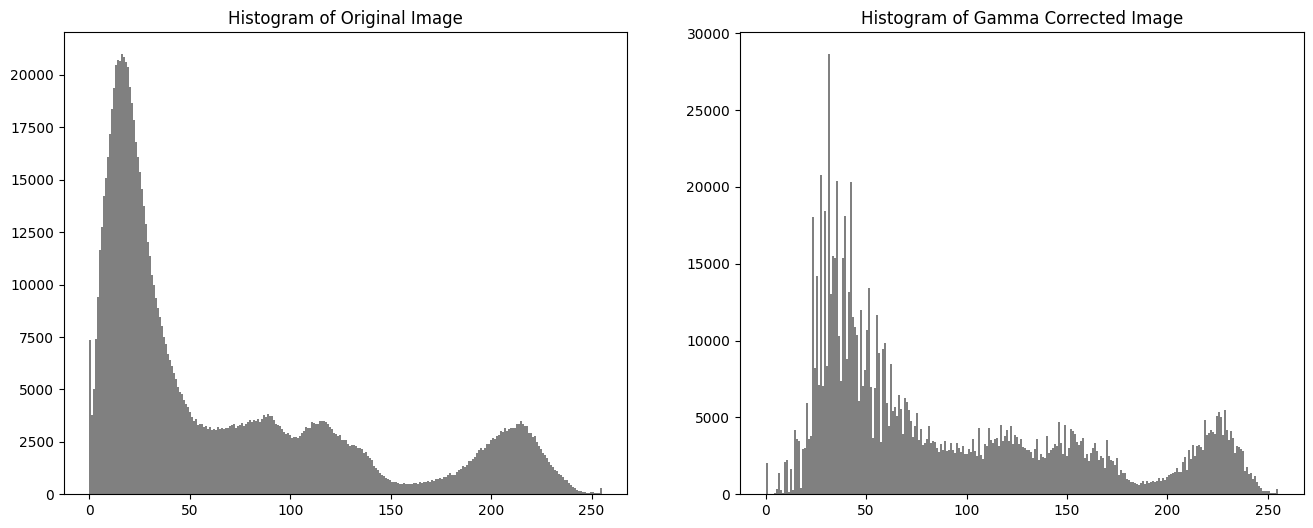

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].hist(im3.ravel(), bins=256, range=(0,255), color='gray')
ax[0].set_title("Histogram of Original Image")

ax[1].hist(corrected_im.ravel(), bins=256, range=(0,255), color='gray')
ax[1].set_title("Histogram of Gamma Corrected Image")

## Question 04


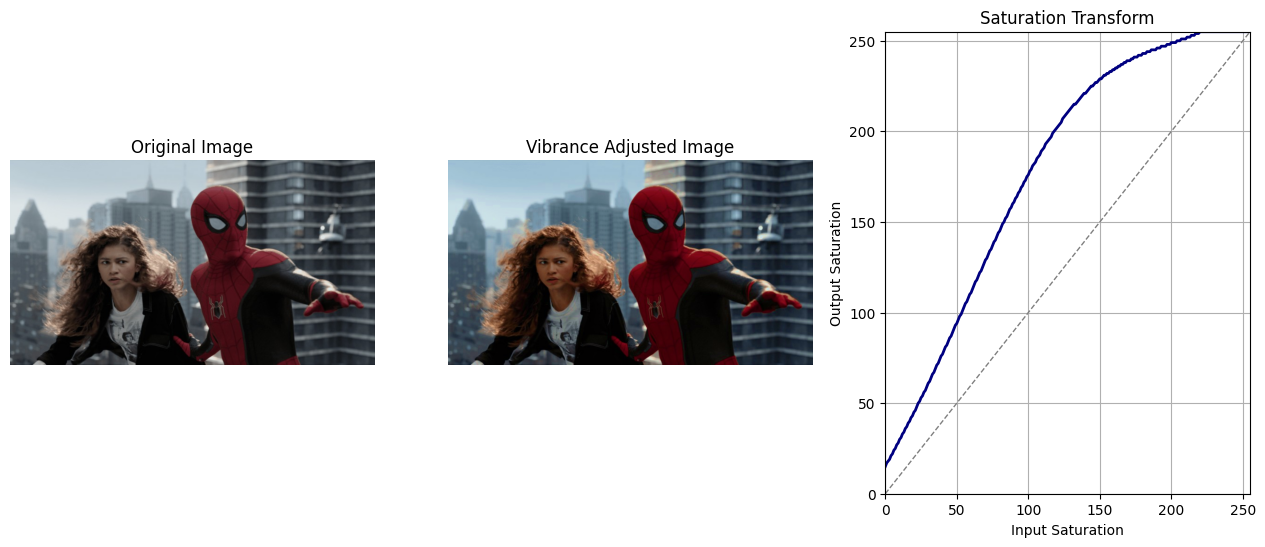

In [ ]:
path = "images/q4.jpeg"
im4 = cv2.imread(path)

def vibrance_transform(x, a, sigma=70):

    x = x.astype(float)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    out = np.minimum(x + boost, 255)

    return out.astype(np.uint8)

#---(a)---
im4_hsv = cv2.cvtColor(im4, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(im4_hsv)

#---(b) & (c)---
a = 0.65
s_new = vibrance_transform(s, a)

#---(d)---
im4_hsv_new = cv2.merge([h, s_new, v])
im4_bgr_new = cv2.cvtColor(im4_hsv_new, cv2.COLOR_HSV2BGR)

#---(e)---
xs = np.arange(0, 256)
lut2 = vibrance_transform(xs, a)

### Discussion

Unlike linear Saturation boost, this transformation function applies gaussian weighted boost centered at mid saturation values, rather than applying to all values uniformly. This means that the pixesl that are already near-gray (or has low saturation) and highly saturatied pixels will recieve almost no boost in saturation. This means features like sky, skin highlights will recieve very less saturation, and only dull looking pixels (like MJ's hair) will be boosted.

This results in a natural vibrance effect. Applying the transformation to only the S plane ensures the true colors and brightness of the original image are preserved.

After experimentin with multiple values for a, which controls how much of the said boost is applied, I concluded that a = 0.65 gives the most visually pleasing output. 

## Question 05

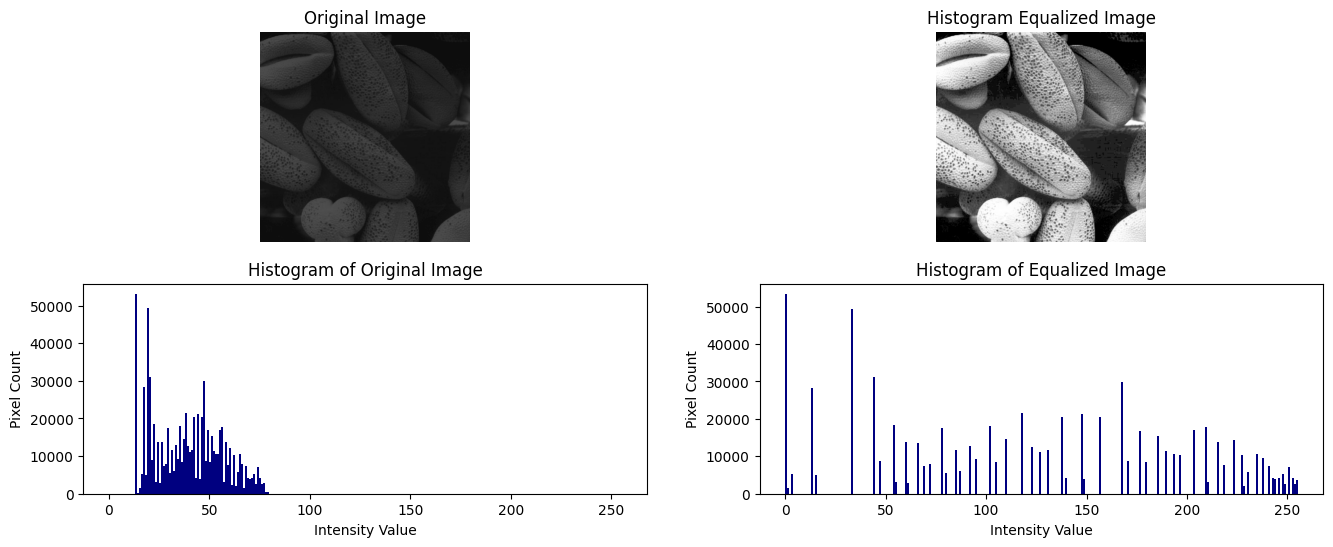

In [ ]:
def histogram_equalization(im):

    hist, bins = np.histogram(im.flatten(), bins=256, range=(0, 256))
    
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    total_pixels = im.size

    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    out = lut[im]
    return out, lut

path = "images/shells.tif"
im5 = cv2.imread(path)

out5, lut3 = histogram_equalization(im5)

### Discussion

The original histogram of the "shells.tif" shows pixel intensities concentrated within a narrow range near low intensity values (~10-75), leaving much of the available intensity range unused. Making it difficult to distinguish the features (for examples the shells in the background).

After applying histogram transformation the function remaps intensities according to the image's cdf, making high concentration of pixels stretched and less populated regions compressed. This increases the contrast where information is most dense.




## Question 06

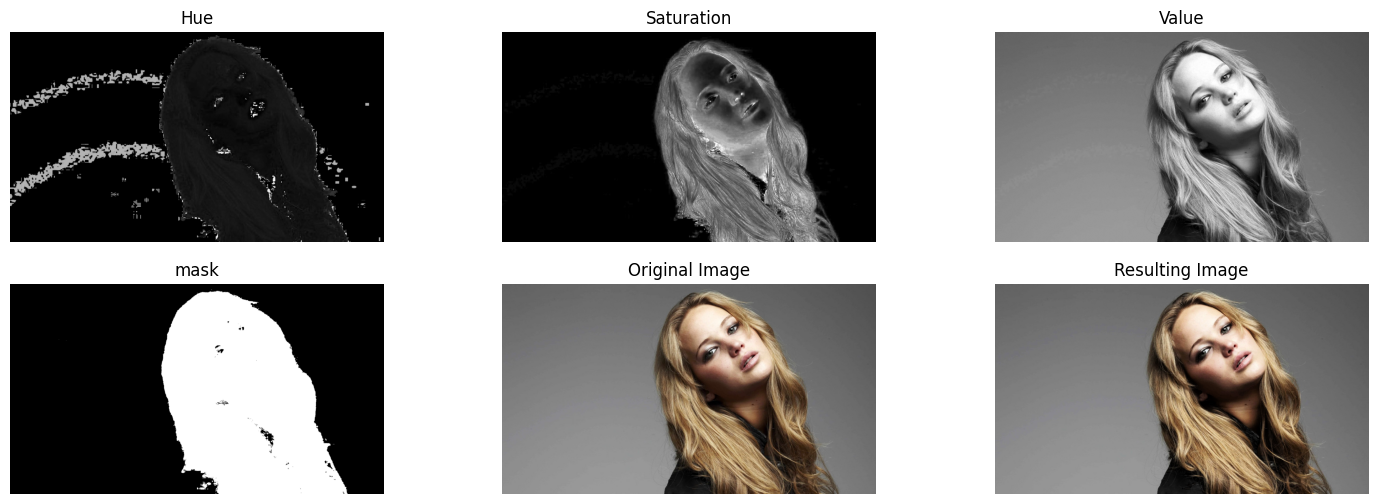

In [ ]:
path = "images/q6.jpeg"
im6_bgr = cv2.imread(path)
im6_hsv = cv2.cvtColor(im6_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(im6_hsv)

Threshold = 14 # choesn from the valey between dark and light pixels
mask = (s > Threshold).astype(np.uint8) * 255

foreground = cv2.bitwise_and(v,v, mask=mask)
hist_fg, _ = np.histogram(foreground[mask==255], bins=256, range=(0, 255))

cdf = np.cumsum(hist_fg)

L = 256
num_fg_pixels = np.sum(mask == 255)

#use the formula give to us to compute the histogram equalization
t = np.array([((L-1)/ num_fg_pixels) * cdf[k] for k in range(256)], dtype=np.uint8)

fg_equalized = np.zeros_like(v)

fg_equalized[mask == 255] = t[v[mask == 255]] #equalization only on foreground

background = cv2.bitwise_and(v, v, mask=cv2.bitwise_not(mask))
v_new = background + fg_equalized

img_hsv_new = cv2.merge([h, s, v_new])
im6_result = cv2.cvtColor(img_hsv_new, cv2.COLOR_HSV2BGR)

### Discussion

Here I used the saturation plane to create the mask as it had the most clear separation between the foreground and the background. Threshold value was selected by analysing the histogram of the saturation plane from the middle point of the valey between lower intensities(darker pixels) and higher intensities (foreground), an after following the rest of the steps and using the formula given in the slides histogram of the foreground was calculated and background and foreground was added.

Using cv2.bitwise_and to separate fg and bg helped here the results of that operations are mutually exclusive and after modifying foreground it can be simply added back.

One limitation I found of this method was that the seem between the bg and fg is slightly visible since no smoothing for that is applied here.


## Question 07

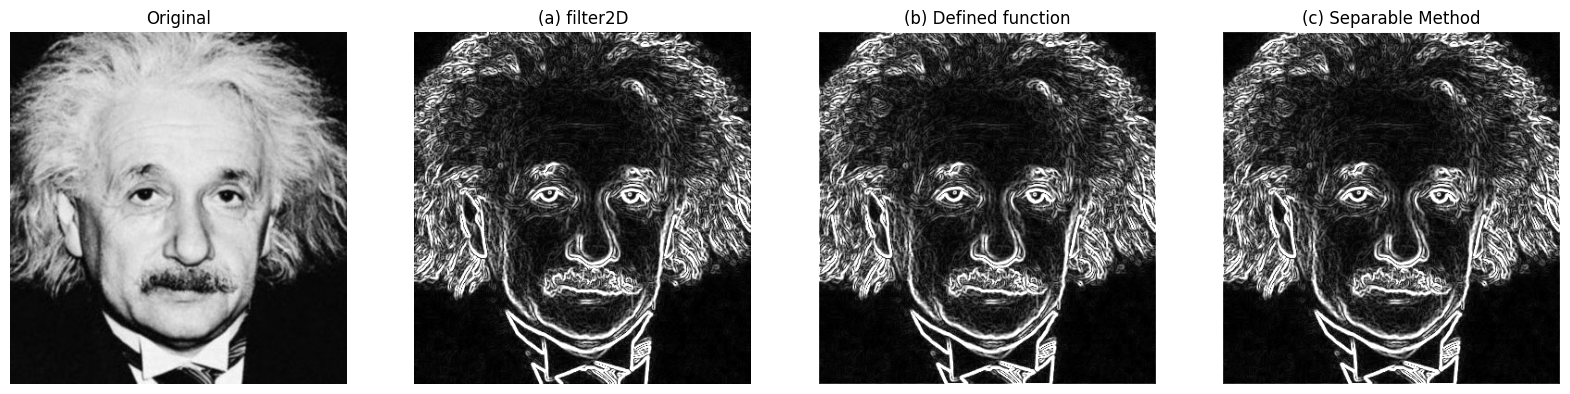

In [33]:
path = "images/q7.jpeg"
im7 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

Gx_kernel = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float32)
Gy_kernel = np.array([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=np.float32)

#---(a)---
gx_a = cv2.filter2D(im7.astype(np.float32), -1, Gx_kernel)
gy_a = cv2.filter2D(im7.astype(np.float32), -1, Gy_kernel)
grad_mag_a = np.sqrt(gx_a**2 + gy_a**2)
grad_mag_a = np.clip(grad_mag_a, 0, 255).astype(np.uint8)

#---(b)---
def defined_sobelfilter(im, kernel):

    im = im.astype(np.float64)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw// 2

    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant') #zero paddint added

    out = np.zeros_like(im)
    H, W = im.shape

    for i in range(H):
        for j in range(W):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)

    return out

gx_b = defined_sobelfilter(im7, Gx_kernel)
gy_b = defined_sobelfilter(im7, Gy_kernel)
grad_mag_b = np.sqrt(gx_b**2 + gy_b**2)
grad_mag_b = np.clip(grad_mag_b, 0, 255).astype(np.uint8)

#---(c)---
def separable_sobel_x(im):
    im = im.astype(np.float64)
    
    c_1 = np.array([[1], [2], [1]], dtype=np.float64)   # (column vector)
    c_2 = np.array([[1, 0, -1]], dtype=np.float64)        # (row vector)
     
    c_1 = defined_sobelfilter(im, c_1)
    out = defined_sobelfilter(c_1, c_2)
    
    return out

gx_c = separable_sobel_x(im7)

def separable_sobel_y(im):
    im = im.astype(np.float64)

    c_3 = np.array([[1, 2, 1]], dtype=np.float64)        
    c_4 = np.array([[1], [0], [-1]], dtype=np.float64) 

    c_3 = defined_sobelfilter(im, c_3)
    out = defined_sobelfilter(c_3, c_4)
    return out

gy_c = separable_sobel_y(im7)

grad_mag_c = np.sqrt(gx_c**2 + gy_c**2)
grad_mag_c = np.clip(grad_mag_c, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(im7, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(grad_mag_a, cmap='gray'); ax[1].set_title('(a) filter2D'); ax[1].axis('off')
ax[2].imshow(grad_mag_b, cmap='gray'); ax[2].set_title('(b) Defined function'); ax[2].axis('off')
ax[3].imshow(grad_mag_c, cmap='gray'); ax[3].set_title('(c) Separable Method'); ax[3].axis('off')
plt.show()

### Discussion

(Since in the question it wasn't mentioned which sobel filter to use I used both.)

All 3 methods produces visually identical gradient magnitude images which menas the secodn and thir method computes the same underlying operation that of cv2.Filter2D. and horizontal Sobel kernel responded strongly to vertical edges and Gy strongly highlighted horizontal edges, overall magnitude of the gradient emphasized edges regardless of thier orientation.

in (b) I defined the function to multiply by 3x3 kernal and take sum and slide the window and repeat technique, with zero-padded input. In part (c) as given in the question each sobel filter can be decomposed in to outer product of two vectors. And then applying these two 1D jernels instead of the 2D kernel as before reduces the computation time significantly if using manual sobel filtering.



## Question 08 

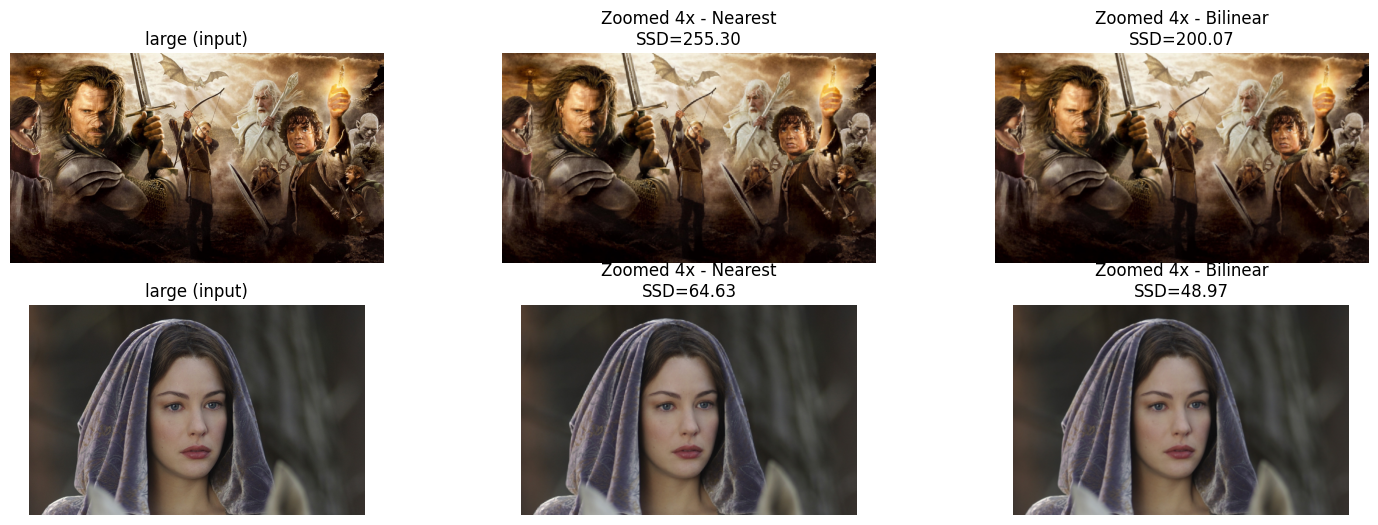

In [ ]:
def zoom_image(im, s, method):

    im = im.astype(np.float64)
    H, W = im.shape
    new_H, new_W = int(round(H*s)), int(round(W*s))

    out = np.zeros((new_H, new_W), dtype = np.float64)

    for i in range(new_H):
        for j in range(new_W):
            y_src = i / s 
            x_src = j / s

            if method == 'nearest':
                y0 = min(int(round(y_src)), H-1)
                x0 = min(int(round(x_src)), W-1)
                out[i, j] = im[y0, x0]

            elif method == 'bilinear':
                x0 = int(np.floor(x_src)); y0 = int(np.floor(y_src))
                x1 = min(x0 + 1, W-1); y1 = min(y0 + 1, H-1)
                x0 = min(x0, W-1); y0 = min(y0 , H-1)

                dx = x_src-x0;dy = y_src-y0

                top = im[y0, x0] * (1 - dx) + im[y0, x1] * dx
                bottom = im[y1, x0] * (1 - dx) + im[y1, x1] * dx
                out[i, j] = top * (1 - dy) + bottom * dy
    return out

def zoom_image_color(im, s, method):
    channels = cv2.split(im)  
    zoomed_channels = [zoom_image(ch, s, method) for ch in channels]
    return cv2.merge(zoomed_channels)

def normalized_ssd(im1, im2):
    """
    Here I defined another function to calculate the normalized ssd.
    """
    im1 = im1.astype(np.float64)
    im2 = im2.astype(np.float64)
    ssd = np.sum((im1 - im2) ** 2)
    normalized = ssd / im1.size
    return normalized

s = 4

#-- for image 01 ---
small_im1 = cv2.imread("images/im01small.png")
large_im1 = cv2.imread("images/im01.png")
zoomed_nn1 = zoom_image_color(small_im1, s, method='nearest')
zoomed_bilinear1 = zoom_image_color(small_im1, s, method='bilinear')
#print(large_im1.shape == zoomed_nn1.shape)
ssd_nn1 = normalized_ssd(zoomed_nn1, large_im1)
ssd_bilinear1 = normalized_ssd(zoomed_bilinear1, large_im1)

#-- for image 02 ---
small_im2 = cv2.imread("images/im02small.png")
large_im2 = cv2.imread("images/im02.png")
zoomed_nn2 = zoom_image_color(small_im2, s, method='nearest')
zoomed_bilinear2 = zoom_image_color(small_im2, s, method='bilinear')
#print(large_im2.shape == zoomed_nn2.shape) #
ssd_nn2 = normalized_ssd(zoomed_nn2, large_im2)
ssd_bilinear2 = normalized_ssd(zoomed_bilinear2, large_im2)

### Discussion

Here since it wasn't mentioned whether to use Grayscale or RGB I defined a function to zoom a given plane and another function to splt a give nimage in to RGB and to call the previous one recursively and merge back together.

From the resulting values of the SSD it can be seen that for nearest-neighbour method results in more errors than the bilinear interpolation method. This is expected because in nearest-neighbour method it rounds up the mappe cordinate and copies it directly, whereas in bilinear interpolation method computes a weighted average of the four surrounding pixels and map corrdinate to each neighbour smoothly.

I also noticed the SSD values for both method in the first image are considerably larger than the second one. This is because of the content in the first image which are multiple figures, fine textures and sharp edges compared to the portrait which has smoother, more uniform regoins. This means that the SSD comparisons are biased to the image content in each one.


## Question 09

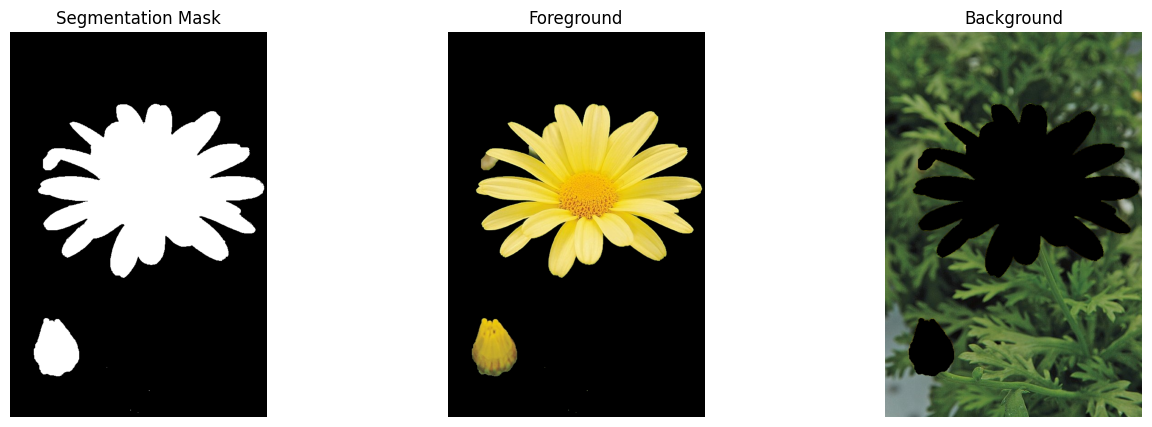

In [ ]:
path = "images/q9.jpeg"
im9_src = cv2.imread(path)
im9 = cv2.cvtColor(im9_src, cv2.COLOR_BGR2RGB)

mask = np.zeros(im9.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

h, w = im9.shape[:2]
rect = (int(w*0.05), int(h*0.05),int(w*0.95),int(h*0.95)) #manually adjusted to get the flowers 
cv2.grabCut(im9, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask_binary = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

foreground = im9 * mask_binary[:, :, np.newaxis]
background = im9 * (1 - mask_binary[:, :, np.newaxis])

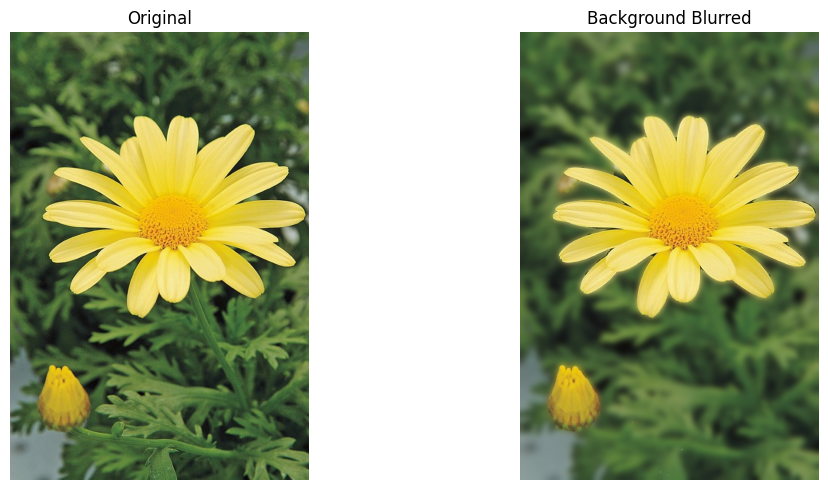

In [ ]:
#---(b)---
blurred = cv2.GaussianBlur(im9_src, (35, 35), 0)
blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

mask_3ch = mask_binary[:, :, np.newaxis]
enhanced = im9 * mask_3ch + blurred_rgb * (1 - mask_3ch)
enhanced = enhanced.astype(np.uint8)

### (c) 

Gaussian blur works by averaging each pixel with its neighbours in a wondow(here I use 35x35 kernel). Near the boundry between the flower and the background the window includes both background pixels and foreground pixels, resulting in dark pixels mixed in from background to create a darker line.

### Discussion 

in part a I used grabCut iteratively to model fgd and bgd as seperate models then using a graph-cut algorithm to find the globally optimal foreground/background.The algorithm was initialized with a rectangular bounding box roughly enclosing the flower, which tells GrabCut that everything outside the rectangle is definite background, while everything inside is initially treated as foreground and iteratively refined. The mask distinguishes definite background as 0 and definite foreground as 1. and combininig the probable and definite foregrounds the completed mask was created.

in part b I blurred the entire image and then composited the sharp, unblurred foreground from before using the segmentation mask from before.


## Question 10 

### (a)

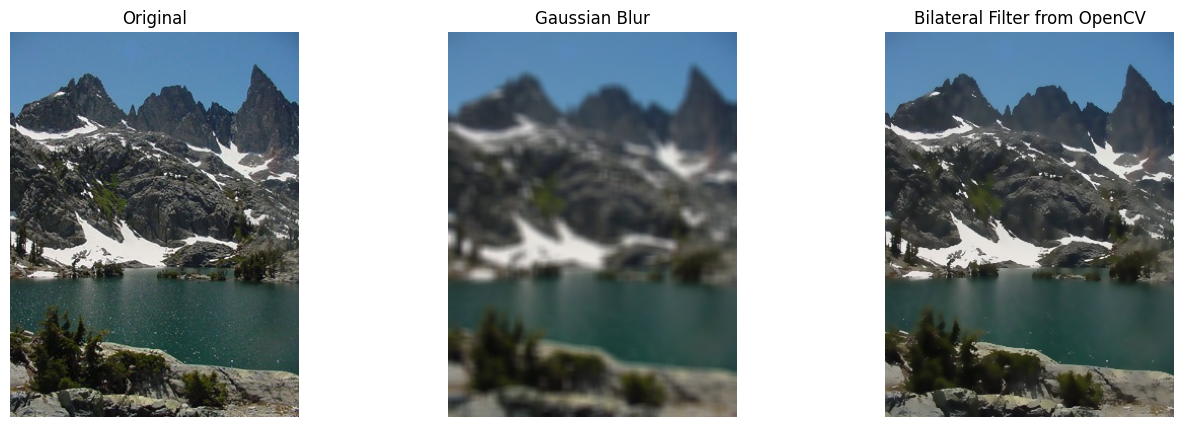

In [56]:
path = "images/q10.jpeg"
im10 = cv2.imread(path)

sigma_s = 75; sigma_r = 75
bilateral_cv = cv2.bilateralFilter(im10, 9, sigma_r, sigma_s)
gaussian = cv2.GaussianBlur(im10, (9,9), sigma_s)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(cv2.cvtColor(im10, cv2.COLOR_BGR2RGB)); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB)); ax[1].set_title('Gaussian Blur'); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(bilateral_cv, cv2.COLOR_BGR2RGB)); ax[2].set_title('Bilateral Filter from OpenCV'); ax[2].axis('off')
plt.show()

### (b)

Defined function & OpenCV bilateral filter SSD: 29.09384


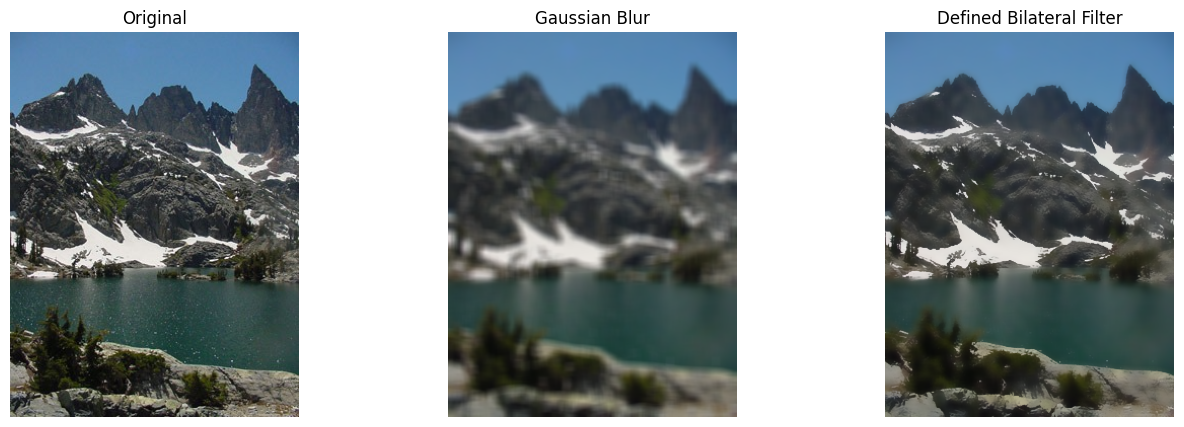

In [57]:
def defined_bilateral_filter(im, d, sigma_s, sigma_r):

    im = im.astype(np.float64)
    H, W, C = im.shape
    radius = d // 2
    padded = np.pad(im, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')

    out = np.zeros_like(im)

    ax_range = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax_range, ax_range)
    spatial_weights = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))

    for i in range(H):
        for j in range(W):
            region = padded[i:i+d, j:j+d, :]
            center_val = padded[i+radius, j+radius, :]

            diff = region - center_val
            color_dist_sq = np.sum(diff**2, axis=2)

            range_weights = np.exp(-color_dist_sq / (2 * sigma_r**2))
            weights = spatial_weights * range_weights

            weights_3ch = weights[:, :, np.newaxis]
            out[i, j, :] = np.sum(region * weights_3ch, axis=(0,1)) / np.sum(weights)

    return out

bilateral_own = np.clip(defined_bilateral_filter(im10, 9, sigma_s, sigma_r), 0, 255).astype(np.uint8) 

ssd = normalized_ssd(bilateral_own, bilateral_cv) # I used previously defined normalization function here (from Q08)
print(f"Defined function & OpenCV bilateral filter SSD: {ssd:.5f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(cv2.cvtColor(im10, cv2.COLOR_BGR2RGB)); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB)); ax[1].set_title('Gaussian Blur'); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(bilateral_own, cv2.COLOR_BGR2RGB)); ax[2].set_title(f'Defined Bilateral Filter'); ax[2].axis('off')
plt.show()

### Discussion

The Gaussian-blurred image shows smoothing applied for the whole image, including for the strong edges. The bilateral filter from the cv2 library, weights are assigned not just based on spatial distance but intensity also. Which is why in that output image sharp edges like between mountain peak and the sky.

The normalized SSD between the defined implementation and OpenCV's result was about 29. This discrepancy is expected because OpenCV's bilateralFilter uses internal numerical optimizations that trade a small amount of accuracy for improved execution speed, particularly important given that a naive per-pixel double-loop implementation (as used here) is computationally expensive which explains why it takes to run longer compared to part a.
